In [1]:
import numpy as np
import matplotlib.pyplot as plt

def MoireFind(phiin,delta,degtol,lattol,select):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle =',phiin)

    print('Input Bot Angle =', phiin)
    print('Input Delta =', delta)

    m0a = []
    m0p = []
    m0b = []
    Flag = True
    
    a = 21
    b = 20
    ap = 20
    bp = 21
    
    for supk in range(0,10):
        for app in range(0,supk*21):
            for bpp in range(0,supk*21):
                m = np.array([[a*supk,b*supk],
                              [-b*supk,a*supk+b*supk]])
                mp2 = np.array([[app,bpp],
                                [-bpp,app+bpp]])
                Temp1 = 2*app*a*supk + 2*bpp*b*supk + app*b*supk + bpp*a*supk
                Gamma = a*supk*a*supk + b*supk*b*supk + a*supk*b*supk
                Temp2 = app*app + bpp*bpp + app*bpp
                p = np.sqrt(Temp2/Gamma)
                alpha = np.arccos(np.real(Temp1/(2.0*p*Gamma)))
                d = p - 1.0
                ep = abs(d-delta)
                ea = abs(alpha - phi)
                if (ea < ea0):
                    ea0 = ea
                    m0a = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
                if (ep < ep0):
                    ep0 = ep
                    m0p = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
                e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                if (e < e0):
                    e0 = e
                    m0b = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
    if select == 'angle':
        a = m0a[0][0]
        b = m0a[0][1]
        ap = m0a[1][0]
        bp = m0a[1][1]
        app = m0a[2][0]
        bpp = m0a[2][1]
    elif select == 'delta':
        a = m0p[0][0]
        b = m0p[0][1]
        ap = m0p[1][0]
        bp = m0p[1][1]
        app = m0p[2][0]
        bpp = m0p[2][1]
    elif select == 'both':
        a = m0b[0][0]
        b = m0b[0][1]
        ap = m0b[1][0]
        bp = m0b[1][1]
        app = m0b[2][0]
        bpp = m0b[2][1]
    else:
        print('Choose angle as autometically. Your select input is wrong')
        a = m0a[0][0]
        b = m0a[0][1]
        ap = m0a[1][0]
        bp = m0a[1][1]
        app = m0a[2][0]
        bpp = m0a[2][1]
    Temp1 = 2*app*a + 2*bpp*b + app*b + bpp*a
    Gamma = a*a + b*b + a*b
    Temp2 = app*app + bpp*bpp + app*bpp
    p = np.sqrt(Temp2/Gamma)
    alpha = np.arccos(np.real(Temp1/(2.0*p*Gamma)))    
    print('Final result: ',a,b,ap,bp,app,bpp,d,alpha*180.0/np.pi,Temp1,Temp2)

    mout = np.array([[a,b],
                     [ap,bp],
                     [app,bpp]])
    return mout



In [33]:
n1 = 1
n2 = 80

aG = 2.4602 #float(input())
aBN = 2.4602 #float(input())


degtol = 0.5
lattol = 0.1

select = 'delta' #input()

phideg = 1.538
delta = aBN/aG-1.0
deltol = (aBN+lattol)/aG-1.0-delta

Factor = 200

# Call moire Find function
nInit = MoireFind(phideg,delta,degtol,deltol,select)

Input Bot Angle = 1.538
Input Delta = 0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:34: RuntimeWarning: invalid value encountered in double_scalars
/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:48: RuntimeWarning: divide by zero encountered in double_scalars


Final result:  189 180 180 189 181 188 0.01886917654777509 1.4342731844885404 204210 102133


In [86]:
import numpy as np
def MoireFind(supk,a0,b0,phiin,delta,degtol,lattol):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180.0
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle = ',phiin)
    print('Delta = ',delta)
    for supk in range(supk):
        a = supk*a0
        b = supk*b0
        for ap in range(a+5):
            for bp in range(a+5):
                m = [[a,b],
                     [-b,a+b]]
                mp = [[ap,bp],
                      [-bp,ap+bp]]
                mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
                      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
                N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
                g = a**2+b**2+a*b
                if g == 0:
                    g = 0.000000000001
                p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
                nn = 2*a*ap+2*b*bp+b*ap+a*bp
                alpha = np.arccos(np.real(nn)/(2*p*g))
                pcomp = p
                d = pcomp-1
                ep = abs(d-delta)
                ea = abs(alpha-phi)
                if ep < lattol and ea < degtol:
                    if (ea < ea0):
                        ea0 = ea
                        m0a = np.array([[a,b],
                                        [ap,bp]])
                        #if (ep < ep0):
                        #    ep0 = ep
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
                        #e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                        #if (e < e0):
                        #    e0 = e
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
    a = m0a[0][0]
    b = m0a[0][1]
    ap = m0a[1][0]
    bp = m0a[1][1]
    m = [[a,b],
         [-b,a+b]]
    mp = [[ap,bp],
          [-bp,ap+bp]]
    mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
          [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
    N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
    g = a**2+b**2+a*b
    p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
    nn = 2*a*ap+2*b*bp+b*ap+a*bp
    alpha = np.arccos(np.real(nn)/(2*p*g))
    print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)
    mout = m0a
    return mout

In [118]:
degtol = 0.001
lattol = 0.01

angle = 1.45
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol)
NewL = 2.46*1.0116258231462048
print(NewL)

Angle =  1.45
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars


198 189 190 198 angle =  1.451274059714003 aBN = 2.466309034396192
2.4885995249396635


In [119]:
degtol = 0.001
lattol = 0.01

angle = 1.8
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol)
NewL = 2.46*1.0116258231462048
print(NewL)

Angle =  1.8
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars


198 189 187 199 angle =  1.7975250013180037 aBN = 2.453817433142381
2.4885995249396635


In [97]:
degtol = 0.001
lattol = 0.01

angle = 1.6
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol)
NewL = 2.46*1.0116258231462048
print(NewL)

Angle =  1.6
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars


198 189 190 200 angle =  1.6173862559455556 aBN = 2.479117946988668
2.4885995249396635


In [121]:
degtol = 0.001
lattol = 0.01

angle = 1.65
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol)
NewL = 2.46*1.0116258231462048
print(NewL)

Angle =  1.65
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars


154 147 146 154 angle =  1.651306452908811 aBN = 2.451896811129329
2.4885995249396635


In [122]:
(2.4665-2.4602)/2.4602

0.0025607674172831367

In [137]:
degtol = 0.001
lattol = 0.01

angle = 1.537
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol)
NewL = 2.46*1.0116258231462048
print(NewL)

Angle =  1.537
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in double_scalars


22 21 23 20 angle =  1.537391522016103 aBN = 2.4617729732031277
[[22 21]
 [23 20]]
2.4885995249396635


In [124]:
3.075891-1.537392

1.5384989999999998

[31.98247, 17.044696305091502] [1.2300949999999986, 36.219979648319445]
28.054880915496177 28.05488091549617
[36.24086173690824, 0.0] [18.120430868454115, 31.385506919201973] 28.054880915496177
9 8 7 10 angle =  7.762644728947333 aBN = 2.47131040446306
9 8 8 9 angle =  3.8902381690076835 aBN = 2.46


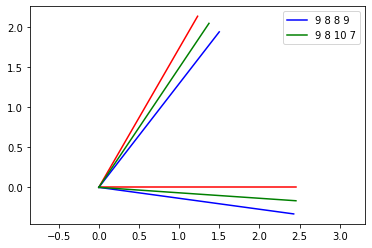

In [248]:
#Try build structure:
import matplotlib.pyplot as plt
import numpy as np

def MoireFind(supk,a0,b0,phiin,delta,degtol,lattol):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180.0
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle = ',phiin)
    print('Delta = ',delta)
    for supk in range(supk):
        a = supk*a0
        b = supk*b0
        for ap in range(a+5):
            for bp in range(a+5):
                m = [[a,b],
                     [-b,a+b]]
                mp = [[ap,bp],
                      [-bp,ap+bp]]
                mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
                      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
                N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
                g = a**2+b**2+a*b
                if g == 0:
                    g = 0.000000000001
                p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
                nn = 2*a*ap+2*b*bp+b*ap+a*bp
                alpha = np.arccos(np.real(nn)/(2*p*g))
                pcomp = p
                d = pcomp-1
                ep = abs(d-delta)
                ea = abs(alpha-phi)
                if ep < lattol and ea < degtol:
                    if (ea < ea0):
                        ea0 = ea
                        m0a = np.array([[a,b],
                                        [ap,bp]])
                        #if (ep < ep0):
                        #    ep0 = ep
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
                        #e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                        #if (e < e0):
                        #    e0 = e
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
    a = m0a[0][0]
    b = m0a[0][1]
    ap = m0a[1][0]
    bp = m0a[1][1]
    m = [[a,b],
         [-b,a+b]]
    mp = [[ap,bp],
          [-bp,ap+bp]]
    mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
          [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
    N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
    g = a**2+b**2+a*b
    p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
    nn = 2*a*ap+2*b*bp+b*ap+a*bp
    alpha = np.arccos(np.real(nn)/(2*p*g))
    print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)
    mout = m0a
    return mout

def GetR(a,b,Ro1,Ro2):
    mp = np.array([[a,b],[-b,a+b]])
    invmp = np.linalg.inv(mp)
    
    R1 = [0,0] #[mp[0][0]*Ro1[0]+mp[0][1]*Ro1[1],mp[1][0]*Ro1[0]+mp[1][1]*Ro1[1]]
    R2 = [0,0] #[mp[0][0]*Ro2[0]+mp[0][1]*Ro2[1],mp[1][0]*Ro2[0]+mp[1][1]*Ro2[1]]
    R1[0] = mp[0][0]*Ro1[0]+mp[0][1]*Ro2[0]
    R1[1] = mp[0][0]*Ro1[1]+mp[0][1]*Ro2[1]
    R2[0] = mp[1][0]*Ro1[0]+mp[1][1]*Ro2[0]
    R2[1] = mp[1][0]*Ro1[1]+mp[1][1]*Ro2[1]
    
    return R1,R2

def Aligned(R1,R2):
    lenR1 = np.sqrt(R1[0]**2+R1[1]**2)
    lenR2 = np.sqrt(R2[0]**2+R2[1]**2)
    AngleR1 = np.arccos(R1[0]/lenR1)
    AngleR1_b = np.arcsin(R1[1]/lenR1)

    print(AngleR1*180/np.pi,AngleR1_b*180/np.pi)    
    Angle = AngleR1

    TwistMatrix = np.array([[np.cos(Angle),np.sin(Angle)],[-np.sin(Angle),np.cos(Angle)]])
    NewR1 = [0,0]
    NewR2 = [0,0]
    
    NewR1[0] = TwistMatrix[0][0]*R1[0]+TwistMatrix[0][1]*R1[1]
    NewR1[1] = TwistMatrix[1][0]*R1[0]+TwistMatrix[1][1]*R1[1]
    
    NewR2[0] = TwistMatrix[0][0]*R2[0]+TwistMatrix[0][1]*R2[1]
    NewR2[1] = TwistMatrix[1][0]*R2[0]+TwistMatrix[1][1]*R2[1]
    
    return NewR1,NewR2,Angle

Ro1 = [2.46019,0]
Ro2 = [2.46019/2,np.sqrt(3)*2.46019/2]

degtol = 1
lattol = 0.001

angle = 7
aBN = 2.46
aG = 2.46
delta = aBN/aG-1

#mout = MoireFind(10,9,8,angle,delta,degtol,lattol)
mout = [[9,8],
       [7,10]]

R1,R2 = GetR(mout[0][0],mout[0][1],Ro1,Ro2)
print(R1,R2)

NewR1,NewR2,Angle = Aligned(R1,R2)
print(NewR1,NewR2,Angle*180/np.pi)
#plt.plot([0,R1[0]],[0,R1[1]],'r')
#plt.plot([0,NewR1[0]],[0,NewR1[1]])
#plt.plot([0,R2[0]],[0,R2[1]],'r')
#plt.plot([0,NewR2[0]],[0,NewR2[1]])
plt.axis('equal')

TwistMatrix = np.array([[np.cos(Angle),np.sin(Angle)],[-np.sin(Angle),np.cos(Angle)]])
NewRo1 = [0,0]
NewRo2 = [0,0]

NewRo1[0] = TwistMatrix[0][0]*Ro1[0]+TwistMatrix[0][1]*Ro1[1]
NewRo1[1] = TwistMatrix[1][0]*Ro1[0]+TwistMatrix[1][1]*Ro1[1]

NewRo2[0] = TwistMatrix[0][0]*Ro2[0]+TwistMatrix[0][1]*Ro2[1]
NewRo2[1] = TwistMatrix[1][0]*Ro2[0]+TwistMatrix[1][1]*Ro2[1]

plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 8 9')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

mout = [[9,8],
       [8,9]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

In [175]:
degtol = 0.001
lattol = 0.01

angle = 1.537
aBN = 2.46
aG = 2.46
delta = aBN/aG-1
mout = MoireFind2(10,22,21,angle,delta,degtol,lattol)
mout = MoireFind(10,22,21,angle,delta,degtol,lattol)

Angle =  1.537
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:93: RuntimeWarning: invalid value encountered in double_scalars


22 21 23 20 angle =  1.537391522016103 aBN = 2.4617729732031277
Angle =  1.537
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in double_scalars


22 21 23 20 angle =  1.537391522016103 aBN = 2.4617729732031277


198 189 190 197 angle =  1.3675695964261612 aBN = 2.4599124126574115
198 189 189 198 angle =  1.5384998183717071 aBN = 2.46


(-0.1230095, 2.5831995, -0.1758847987502689, 2.240419030369138)

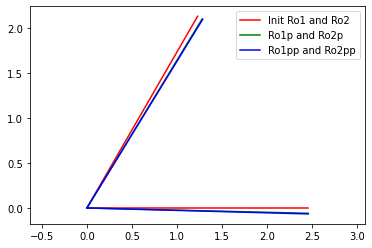

In [98]:
Ro1 = [2.46019,0]
Ro2 = [2.46019/2,np.sqrt(3)*2.46019/2]

plt.plot([0,Ro1[0]],[0,Ro1[1]],'r',label = 'Init Ro1 and Ro2')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[198,189],
       [190,197]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = 'Ro1p and Ro2p')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[198,189],
       [189,198]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = 'Ro1pp and Ro2pp')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

198 189 190 198 angle =  1.451274059714003 aBN = 2.466309034396192
198 189 189 198 angle =  1.5384998183717071 aBN = 2.46


(-0.1230095, 2.5831995, -0.1758847987502689, 2.240419030369138)

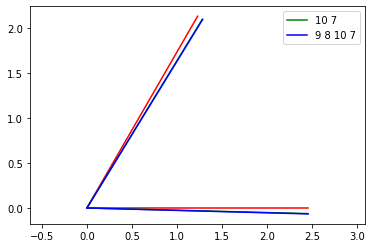

In [190]:
plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[198,189],
       [190,198]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[198,189],
       [189,198]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

110 105 104 109 angle =  1.5457219419907888 aBN = 2.437120423110267
110 105 105 110 angle =  1.5384998183717071 aBN = 2.46


(-0.12411912643610612,
 2.6065016551582287,
 -0.17686445422945835,
 2.240465680630052)

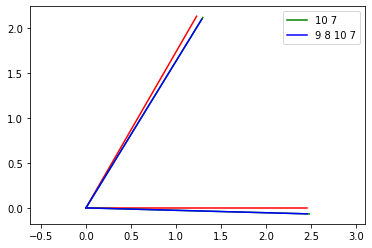

In [191]:
plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[110,105],
       [104,109]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[110,105],
       [105,110]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

198 189 190 200 angle =  1.6173862559455556 aBN = 2.479117946988668
198 189 189 198 angle =  1.5384998183717071 aBN = 2.46


(-0.1230095, 2.5831995, -0.1788778136005963, 2.2405615548858204)

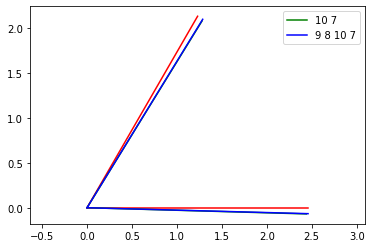

In [192]:
plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[198,189],
       [190,200]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[198,189],
       [189,198]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

154 147 146 154 angle =  1.651306452908811 aBN = 2.451896811129329
154 147 147 154 angle =  1.5384998183717071 aBN = 2.46


(-0.1233647765640737,
 2.5906603078455475,
 -0.18121476489274427,
 2.2406728382806844)

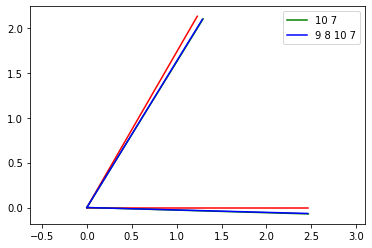

In [193]:
plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[154,147],
       [146,154]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[154,147],
       [147,154]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

110 105 104 110 angle =  1.6966380830391092 aBN = 2.4486582091493125
110 105 105 110 angle =  1.5384998183717071 aBN = 2.46


(-0.12352508295494234,
 2.594026742053789,
 -0.18336592602054452,
 2.2407752745248657)

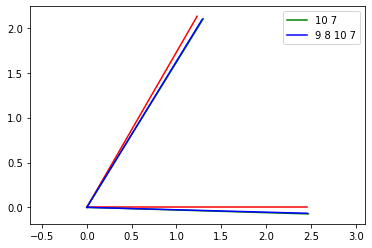

In [194]:
plt.plot([0,Ro1[0]],[0,Ro1[1]],'r')
#plt.plot([0,NewRo1[0]],[0,NewRo1[1]])
plt.plot([0,Ro2[0]],[0,Ro2[1]],'r')
#plt.plot([0,NewRo2[0]],[0,NewRo2[1]])

mout = [[110,105],
       [104,110]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'g',label = '10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'g')

plt.legend()

mout = [[110,105],
       [105,110]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46*p)

Ro1p = [0,0]
Ro2p = [0,0]

mp = np.array([[a,b],[-b,a+b]])
m = np.array([[ap,bp],[-bp,ap+bp]])
invm = np.linalg.inv(m)

Temp = [[0,0],[0,0]]
Temp[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
Temp[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
Temp[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
Temp[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p[0] = Temp[0][0]*Ro1[0]+Temp[0][1]*Ro2[0]
Ro1p[1] = Temp[0][0]*Ro1[1]+Temp[0][1]*Ro2[1]
Ro2p[0] = Temp[1][0]*Ro1[0]+Temp[1][1]*Ro2[0]
Ro2p[1] = Temp[1][0]*Ro1[1]+Temp[1][1]*Ro2[1]

plt.plot([0,Ro1p[0]],[0,Ro1p[1]],'b',label = '9 8 10 7')
plt.plot([0,Ro2p[0]],[0,Ro2p[1]],'b')

plt.legend()
plt.axis('equal')

In [250]:
mout = [[110,105],
       [104,109]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019*p)

110 105 104 109 angle =  1.5457219419907888 aBN = 2.437308655988475


In [288]:
mout = [[110*8,105*8],
       [104*8.0562,109*8.0562]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019*p)

880 840 837.8448000000001 878.1258 angle =  1.5457219419907888 aBN = 2.4544307492967943


In [15]:
mout = [[22*40,21*40],
       [21*41,22*41]]

a = 8#mout[0][0]
b = 9#mout[0][1]
ap = 9#mout[1][0]
bp = 8#mout[1][1]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019*p)

8 9 9 8 angle =  3.8902381690076835 aBN = 2.46019


In [4]:
def MoireFind(supk,a0,b0,phiin,delta,degtol,lattol):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180.0
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle = ',phiin)
    print('Delta = ',delta)
    for supk in range(supk):
        a = supk*a0
        b = supk*b0
        for ap in range(a+5):
            for bp in range(a+5):
                m = [[a,b],
                     [-b,a+b]]
                mp = [[ap,bp],
                      [-bp,ap+bp]]
                mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
                      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
                N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
                g = a**2+b**2+a*b
                if g == 0:
                    g = 0.000000000001
                p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
                nn = 2*a*ap+2*b*bp+b*ap+a*bp
                alpha = np.arccos(np.real(nn)/(2*p*g))
                pcomp = p
                d = pcomp-1
                ep = abs(d-delta)
                ea = abs(alpha-phi)
                if ep < lattol and ea < degtol:
                    if (ea < ea0):
                        ea0 = ea
                        m0a = np.array([[a,b],
                                        [ap,bp]])
                        #if (ep < ep0):
                        #    ep0 = ep
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
                        #e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                        #if (e < e0):
                        #    e0 = e
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
    a = m0a[0][0]
    b = m0a[0][1]
    ap = m0a[1][0]
    bp = m0a[1][1]
    m = [[a,b],
         [-b,a+b]]
    mp = [[ap,bp],
          [-bp,ap+bp]]
    mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
          [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
    N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
    g = a**2+b**2+a*b
    p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
    nn = 2*a*ap+2*b*bp+b*ap+a*bp
    alpha = np.arccos(np.real(nn)/(2*p*g))
    print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019*p)
    mout = m0a
    return mout

degtol = 0.00001
lattol = 1

angle = 1.545722
aBN = 2.46019
aG = 2.46019
delta = aBN/aG-1
mout = MoireFind(10,22,21,angle,delta,degtol,lattol)

Angle =  1.545722
Delta =  0.0


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in double_scalars


132 126 104 109 angle =  1.5457219419910244 aBN = 2.0310905466570626


[2.46019, 0] [2.4545213594470043, 0.166912348609767]
3.890238169007777
[30.752375, 19.17528334322794] [-1.2300950000000022, 36.219979648319445]
36.24086173690824
31.945119084503823
[36.24086173690824, -7.105427357601002e-15] [18.12043086845412, 31.385506919201973]


(-2.8292185000000023, 32.3514985, -2.7697631495773694, 58.165026141124756)

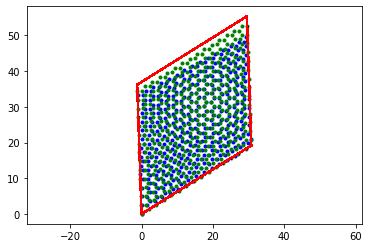

In [84]:
mout = [[8,9],[9,8],[25,15]]

a = mout[0][0]
b = mout[0][1]
ap = mout[1][0]
bp = mout[1][1]
app = mout[2][0]
bpp = mout[2][1]

mp = [[a,b],[-b,a+b]]
m = [[ap,bp],[-bp,ap+bp]]
invm = np.linalg.inv(m)
invmp = np.linalg.inv(mp)

Ro1 = [aG,0]
Ro2 = [aG/2,np.sqrt(3)*aG/2]

tempM = [[0,0],[0,0]]
tempM[0][0] = invm[0][0]*mp[0][0]+invm[0][1]*mp[1][0]
tempM[0][1] = invm[0][0]*mp[0][1]+invm[0][1]*mp[1][1]
tempM[1][0] = invm[1][0]*mp[0][0]+invm[1][1]*mp[1][0]
tempM[1][1] = invm[1][0]*mp[0][1]+invm[1][1]*mp[1][1]

Ro1p = [tempM[0][0]*Ro1[0]+tempM[0][1]*Ro2[0],tempM[0][0]*Ro1[1]+tempM[0][1]*Ro2[1]]
Ro2p = [tempM[1][0]*Ro1[0]+tempM[1][1]*Ro2[0],tempM[1][0]*Ro1[1]+tempM[1][1]*Ro2[1]]

print(Ro1,Ro1p)
lRo1 = np.sqrt(Ro1[0]**2+Ro1[1]**2)
lRo1p = np.sqrt(Ro1p[0]**2+Ro1p[1]**2)
theta = np.arccos((Ro1[0]*Ro1p[0]+Ro1[1]*Ro1p[1])/(lRo1*lRo1p))
print(theta*180/np.pi)

R1 = [mp[0][0]*Ro1[0]+mp[0][1]*Ro2[0],mp[0][0]*Ro1[1]+mp[0][1]*Ro2[1]]
R2 = [mp[1][0]*Ro1[0]+mp[1][1]*Ro2[0],mp[1][0]*Ro1[1]+mp[1][1]*Ro2[1]]
print(R1,R2)
print(np.sqrt((R1[0]**2+R1[1]**2)))

boundary = [[0,0],R1,R2,[R1[0]+R2[0],R1[1]+R2[1]]]

lR1 = np.sqrt(R1[0]**2+R1[1]**2)
AlignedAngle =  np.arccos(R1[0]/lR1)
print(AlignedAngle*180/np.pi)
M = Twistmatrix(-AlignedAngle)

NewR1 = [M[0][0]*R1[0]+M[0][1]*R1[1],M[1][0]*R1[0]+M[1][1]*R1[1]]
NewR2 = [M[0][0]*R2[0]+M[0][1]*R2[1],M[1][0]*R2[0]+M[1][1]*R2[1]]

NewRo1 = [M[0][0]*Ro1[0]+M[0][1]*Ro1[1],M[1][0]*Ro1[0]+M[1][1]*Ro1[1]]
NewRo2 = [M[0][0]*Ro2[0]+M[0][1]*Ro2[1],M[1][0]*Ro2[0]+M[1][1]*Ro2[1]]

NewRo1p = [M[0][0]*Ro1p[0]+M[0][1]*Ro1p[1],M[1][0]*Ro1p[0]+M[1][1]*Ro1p[1]]
NewRo2p = [M[0][0]*Ro2p[0]+M[0][1]*Ro2p[1],M[1][0]*Ro2p[0]+M[1][1]*Ro2p[1]]

print(NewR1,NewR2)

boundary = [[0,0],R1,R2,[R1[0]+R2[0],R1[1]+R2[1]]]
for i in range(-int(lR1/lRo1),3*int(lR1/lRo1)):
    for j in range(-int(lR1/lRo1),3*int(lR1/lRo1)):
        posx = i*NewRo1[0]+j*NewRo2[0]
        posy = i*NewRo1[1]+j*NewRo2[1]
        condition = intheSquare(posx,posy,boundary)
        if condition == True:
            plt.plot(posx,posy,'.b')
        posx = i*NewRo1[0]+j*NewRo2[0]+(NewRo1[0]+NewRo2[0])/3
        posy = i*NewRo1[1]+j*NewRo2[1]+(NewRo1[1]+NewRo2[1])/3
        condition = intheSquare(posx,posy,boundary)
        if condition == True:
            plt.plot(posx,posy,'.b')
            
for i in range(-int(lR1/lRo1),3*int(lR1/lRo1)):
    for j in range(-int(lR1/lRo1),3*int(lR1/lRo1)):
        posx = i*NewRo1p[0]+j*NewRo2p[0]
        posy = i*NewRo1p[1]+j*NewRo2p[1]
        condition = intheSquare(posx,posy,boundary)
        if condition == True:
            plt.plot(posx,posy,'.g')
        posx = i*NewRo1p[0]+j*NewRo2p[0]+(NewRo1p[0]+NewRo2p[0])/3
        posy = i*NewRo1p[1]+j*NewRo2p[1]+(NewRo1p[1]+NewRo2p[1])/3
        condition = intheSquare(posx,posy,boundary)
        if condition == True:
            plt.plot(posx,posy,'.g')

plt.axis('equal')

In [53]:
def Twistmatrix(theta):
    Twist = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
    return Twist

def intheSquare(posx,posy,boundary):
    P1 = boundary[0]
    P2 = boundary[1]
    P3 = boundary[2]
    P4 = boundary[3]

    plt.plot([P2[0],P1[0]],[P2[1],P1[1]],'-r')
    plt.plot([P4[0],P3[0]],[P4[1],P3[1]],'-r')
    plt.plot([P3[0],P1[0]],[P3[1],P1[1]],'-r')
    plt.plot([P4[0],P2[0]],[P4[1],P2[1]],'-r')
    A1 = (P2[1]-P1[1])
    B1 = -(P2[0]-P1[0])
    C1 = (P2[0]-P1[0])*P1[1]-(P2[1]-P1[1])*P1[0]
    d1 = abs(A1*posx+B1*posy+C1)/np.sqrt(A1**2+B1**2)
    A2 = (P4[1]-P2[1])
    B2 = -(P4[0]-P2[0])
    C2 = (P4[0]-P2[0])*P2[1]-(P4[1]-P2[1])*P2[0]
    d2 = abs(A2*posx+B2*posy+C2)/np.sqrt(A2**2+B2**2)
    A3 = (P3[1]-P1[1])
    B3 = -(P3[0]-P1[0])
    C3 = (P3[0]-P1[0])*P1[1]-(P3[1]-P1[1])*P1[0]
    d3 = abs(A3*posx+B3*posy+C3)/np.sqrt(A3**2+B3**2)
    A4 = (P4[1]-P3[1])
    B4 = -(P4[0]-P3[0])
    C4 = (P4[0]-P3[0])*P3[1]-(P4[1]-P3[1])*P3[0]
    d4 = abs(A4*posx+B4*posy+C4)/np.sqrt(A4**2+B4**2)
    condition1 = (P2[1]-P1[1])*(posx-P1[0])-(P2[0]-P1[0])*(posy-P1[1])
    condition2 = (P4[1]-P2[1])*(posx-P2[0])-(P4[0]-P2[0])*(posy-P2[1])
    condition3 = (P3[1]-P1[1])*(posx-P1[0])-(P3[0]-P1[0])*(posy-P1[1])
    condition4 = (P4[1]-P3[1])*(posx-P3[0])-(P4[0]-P3[0])*(posy-P3[1])
    if (condition1 <= 0 and condition2 < 0  and condition3 >= 0 and condition4 > 0):
        return True
    else:
        return False

True


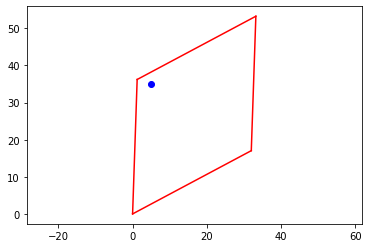

In [51]:
posx = 5
posy = 35

boundary = [[0,0],R1,R2,[R1[0]+R2[0],R1[1]+R2[1]]]


a = intheSquare(posx,posy,boundary)
plt.plot(posx,posy,'ob')
plt.axis('equal')
print(a)

In [37]:
import numpy as np

def MoireFind(supk,a0,b0,phiin,delta,degtol,lattol):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180.0
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle = ',phiin)
    print('Delta = ',delta)
    for supk in range(supk):
        a = supk*a0
        b = supk*b0
        for ap in range(a+5):
            for bp in range(a+5):
                #m = [[ap,bp],
                #     [-bp,ap+bp]]
                #mp = [[a,b],
                #      [-b,a+b]]
                m = [[a,b],
                     [-b,a+b]]
                mp = [[ap,bp],
                      [-bp,ap+bp]]
                mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
                      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
                N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
                g = a**2+b**2+a*b
                if g == 0:
                    g = 0.000000000001
                p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
                nn = 2*a*ap+2*b*bp+b*ap+a*bp
                alpha = np.arccos(np.real(nn)/(2*p*g))
                #if (p<1.0):
                #   pcomp = 1.0/p
                #else:
                pcomp = p 
                d = pcomp-1
                ep = abs(d-delta)
                ea = abs(alpha-phi)
                if ep < lattol and ea < angletol:
                    if (ea < ea0):
                        ea0 = ea
                        m0a = np.array([[a,b],
                                        [ap,bp]])
                        supkFinal = supk
                        #if (ep < ep0):
                        #    ep0 = ep
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
                        #e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                        #if (e < e0):
                        #    e0 = e
                        #    m0a = np.array([[a,b],
                        #                    [ap,bp]])
                        #break 
    a = m0a[0][0]
    b = m0a[0][1]
    ap = m0a[1][0]
    bp = m0a[1][1]
    m = [[a,b],
         [-b,a+b]]
    mp = [[ap,bp],
          [-bp,ap+bp]]
    mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
          [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
    N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
    g = a**2+b**2+a*b
    p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
    nn = 2*a*ap+2*b*bp+b*ap+a*bp
    alpha = np.arccos(np.real(nn)/(2*p*g))
    print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019/p, 'supk =', supkFinal, 'factor = ', 1.0/p)
    mout = m0a 
    return mout

degtol = 0.2 #Tolarance for angle
lattol = 0.003  #Tolarance for lattice mismatch

angle = 1.0 #Expected twisted angle
aBN = 2.504  #Twisted layer expect length
aG = 2.46019   #Reference layer expect length
#aBN = 2.46019   #Reference layer expect length
delta = aBN/aG-1

mout = MoireFind(10,22,21,angle,delta,degtol,lattol) 

Angle =  1.0
Delta =  0.017807567708185257


/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in double_scalars


66 63 69 62 angle =  0.99780898089697 aBN = 2.4216960351464687 supk = 3 factor =  0.9843532552959198


In [62]:
import numpy as np

a = 66
b = 63
ap = 63
bp = 64
m = [[a,b],
     [-b,a+b]]
mp = [[ap,bp],
      [-bp,ap+bp]]
mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
g = a**2+b**2+a*b
p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
nn = 2*a*ap+2*b*bp+b*ap+a*bp
alpha = np.arccos(np.real(nn)/(2*p*g))
print(a,b,ap,bp,'angle = ',alpha*180/np.pi,'aBN =',2.46019/p, 'factor = ', 1.0/p)

66 63 63 64 angle =  1.029718459147061 aBN = 2.499132566037022 factor =  1.0158290888252623


In [66]:
a = np.linspace(30,55,26)

for ap in a:
    print(ap)

[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47.
 48. 49. 50. 51. 52. 53. 54. 55.]
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0


In [3]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import os
from numpy import sqrt
import matplotlib
from matplotlib import gridspec
from matplotlib.pyplot import *

for ap in np.linspace(30,55,26):
    for bp in np.linspace(30,55,26):
        a = 44
        b = 42        
        m = [[a,b],
             [-b,a+b]]
        mp = [[ap,bp],
              [-bp,ap+bp]]
        mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
              [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
        N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
        g = a**2+b**2+a*b
        p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
        nn = 2*a*ap+2*b*bp+b*ap+a*bp
        alpha = np.arccos(np.real(nn)/(2*p*g))
        if abs(alpha*180/np.pi - 1) < 0.2 and abs(2.46019/p-2.505) < 0.05:
            print(a,b,ap,bp,'angle = ',"%.5f"%(alpha*180/np.pi),'aBN =',"%.5f"%(2.46019/p), 'factor = ', "%.5f"%(1.0/p))

44 42 41.0 42.0 angle =  1.16779 aBN = 2.54928 factor =  1.03621
44 42 42.0 43.0 angle =  1.15842 aBN = 2.48930 factor =  1.01183
44 42 44.0 40.0 angle =  0.80558 aBN = 2.51804 factor =  1.02352
44 42 45.0 40.0 angle =  1.17587 aBN = 2.48792 factor =  1.01127


In [1]:
def MoireFind(phiin,delta,degtol,lattol,select):
    angletol = degtol*np.pi/180.0
    phi = phiin*np.pi/180
    ep0 = 10000
    ea0 = 10000
    e0 = 10000
    print('Angle =',phiin)

    print('Input Bot Angle =', phiin)
    print('Input Delta =', delta)

    m0a = []
    m0p = []
    m0b = []
    Flag = True
    
    a = 21
    b = 20
    ap = 20
    bp = 21
    
    for supk in range(0,10):
        for app in range(0,supk*21):
            for bpp in range(0,supk*21):
                m = np.array([[a*supk,b*supk],
                              [-b*supk,a*supk+b*supk]])
                mp2 = np.array([[app,bpp],
                                [-bpp,app+bpp]])
                Temp1 = 2*app*a*supk + 2*bpp*b*supk + app*b*supk + bpp*a*supk
                Gamma = a*supk*a*supk + b*supk*b*supk + a*supk*b*supk
                Temp2 = app*app + bpp*bpp + app*bpp
                p = np.sqrt(Temp2/Gamma)
                alpha = np.arccos(np.real(Temp1/(2.0*p*Gamma)))
                d = p - 1.0
                ep = abs(d-delta)
                ea = abs(alpha - phi)
                if (ea < ea0):
                    ea0 = ea
                    m0a = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
                if (ep < ep0):
                    ep0 = ep
                    m0p = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
                e = np.sqrt(ep**2/delta**2+ea**2/phi**2)
                if (e < e0):
                    e0 = e
                    m0b = np.array([[a*supk,b*supk],
                                    [ap*supk,bp*supk],
                                    [app,bpp]])
    if select == 'angle':
        a = m0a[0][0]
        b = m0a[0][1]
        ap = m0a[1][0]
        bp = m0a[1][1]
        app = m0a[2][0]
        bpp = m0a[2][1]
    elif select == 'delta':
        a = m0p[0][0]
        b = m0p[0][1]
        ap = m0p[1][0]
        bp = m0p[1][1]
        app = m0p[2][0]
        bpp = m0p[2][1]
    elif select == 'both':
        a = m0b[0][0]
        b = m0b[0][1]
        ap = m0b[1][0]
        bp = m0b[1][1]
        app = m0b[2][0]
        bpp = m0b[2][1]
    else:
        print('Choose angle as autometically. Your select input is wrong')
        a = m0a[0][0]
        b = m0a[0][1]
        ap = m0a[1][0]
        bp = m0a[1][1]
        app = m0a[2][0]
        bpp = m0a[2][1]
    Temp1 = 2*app*a + 2*bpp*b + app*b + bpp*a
    Gamma = a*a + b*b + a*b
    Temp2 = app*app + bpp*bpp + app*bpp
    p = np.sqrt(Temp2/Gamma)
    alpha = np.arccos(np.real(Temp1/(2.0*p*Gamma)))    
    print('Final result: ',a,b,ap,bp,app,bpp,d,alpha*180.0/np.pi,Temp1,Temp2)

    mout = np.array([[a,b],
                     [ap,bp],
                     [app,bpp]])
    return mout

/home/jiaqian/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in arccos


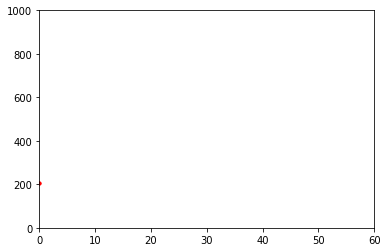

In [17]:
import numpy as np

ang = []
Natom = []

for a in np.linspace(-500,500):
    for b in np.linspace(-500,500):  
        for ap in np.linspace(-500,500):
            for bp in np.linspace(-500,500):
                m = [[a,b],
                     [-b,a+b]]
                mp = [[ap,bp],
                      [-bp,ap+bp]]
                mm = [[m[0][0]-mp[0][0],m[0][1]-mp[0][1]],
                      [m[1][0]-mp[1][0],m[1][1]-mp[1][1]]]
                N = mm[0][0]*mm[1][1] - mm[0][1]*mm[1][0]
                g = a**2+b**2+a*b
                p = np.sqrt(np.real(ap**2+bp**2+ap*bp)/g)
                nn = 2*a*ap+2*b*bp+b*ap+a*bp
                alpha = np.arccos(np.real(nn)/(2*p*g))
                if p == 1:
                    ang.append(alpha*180/np.pi)
                    Natom.append(abs(nn))
                    
plt.xlim([0.0,60])
plt.ylim([0,2000])
plt.plot(ang,Natom,'.r')

Text(0, 0.5, 'Number of atoms')

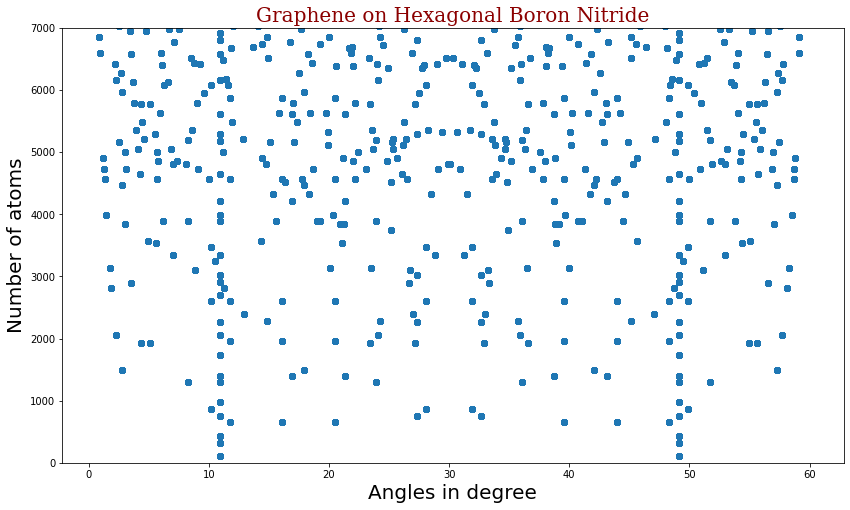

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def supercell_trans_matrices_m(a,b):#Herman equation 25
    m = np.array([[a,b], [-b, a+b]]) # Matrix m
    return m
def supercell_trans_matrices_mp(ap,bp):
    mp = np.array([[ap,bp], [-bp, ap+bp]]) # Matrix m_prime
    return mp

def number_of_moiron(a,b,ap,bp):#Hermann equation 24
    m = supercell_trans_matrices_m(a,b)
    mp = supercell_trans_matrices_mp(ap,bp)
    N = np.linalg.det(m-mp)
    return N

def number_of_atoms_in_1Moiron(a,b,ap,bp): #Hermann equation 30
    A = (ap - a)**2 + (bp - b)**2 + (ap - a)*(bp - b)  #Herman, Equation 31
    x = np.array([[(ap+bp)*(b-bp)+ap*(a-ap), (a*bp - b*ap)], [(b*ap - a*bp), (ap+bp)*(a-ap)+bp*(b-bp)]])
    final_matrix= x/A
    n = np.linalg.det(final_matrix)
    return n * 4 #2 atoms per unit cell in graphene

def total_atoms_per_Supercell(a,b,ap,bp):
    n = number_of_atoms_in_1Moiron(a,b,ap,bp)
    N = number_of_moiron(a,b,ap,bp)
    return round(N*n)

def alpha(a,b,ap,bp,p):#Herman equation 29
#     p = 0.98
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = alpha_rad*180/np.pi
    return alpha_deg

def p_param(a,b,ap,bp):
    return np.sqrt((ap**2+bp**2+ap*bp)/(a**2+b**2+a*b))

def P_range(): # Considering the tolerance of substrate lattice parameters, we will now have a range of 'P' values.
    R0p = 2.506  # Lattice constant of BN
    R0 = 2.4602   # Lattice constant of graphene
    tol = 0.001
    return R0/(R0p), R0/(R0p - tol)

plw,phi = P_range()

angles = []
num_atom = []

for a in range(-50,50):
        for b in range(-50,50):
            for ap in range(-50, 50):
                for bp in range(-50,50):
                    if (a != ap and b != bp and a != 0 and b != 0):
                        p = p_param(a,b,ap,bp)
                        if plw <= p <= phi:
                            num_atom.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles.append(angle)

angles2 = [x - 120 if x > 120 else x for x in angles]

angles3 = [x - 60 if x > 60 else x for x in angles2]

plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
        'color':  'darkred','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

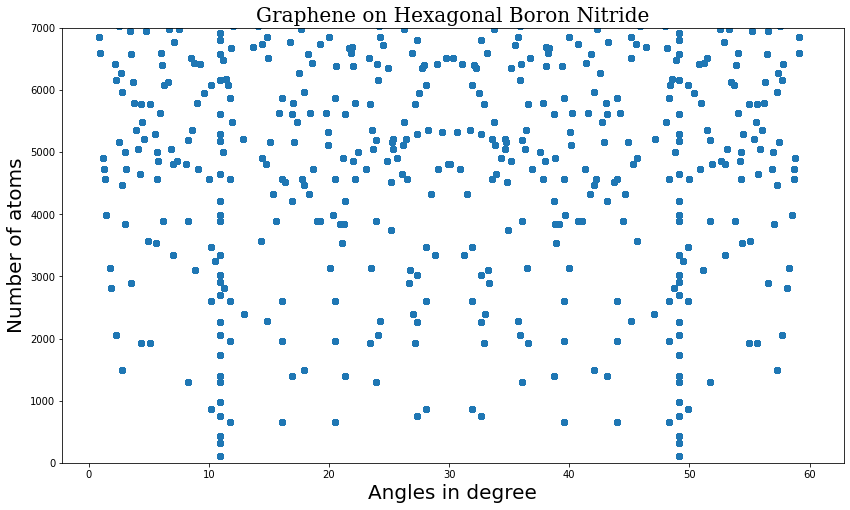

In [38]:
plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

plt.savefig("2.4602_2.505.jpg",dpi=400,bbox_inches="tight")

Text(0, 0.5, 'Number of atoms')

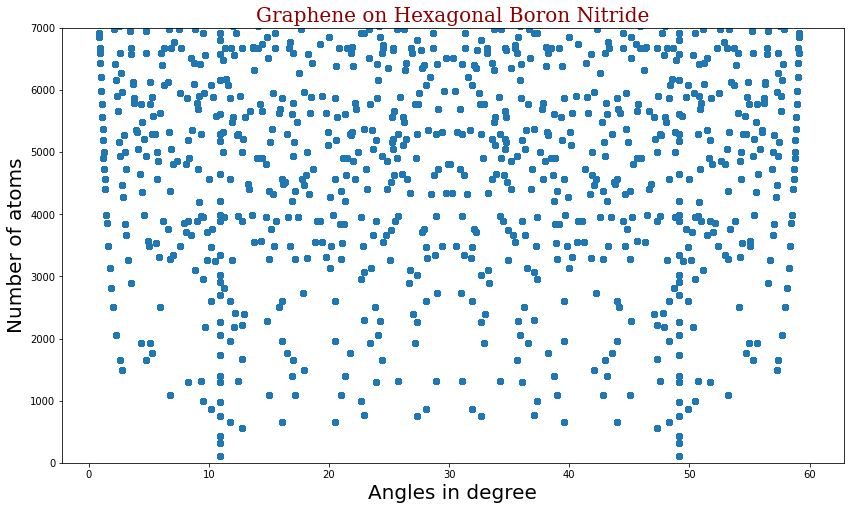

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def supercell_trans_matrices_m(a,b):#Herman equation 25
    m = np.array([[a,b], [-b, a+b]]) # Matrix m
    return m
def supercell_trans_matrices_mp(ap,bp):
    mp = np.array([[ap,bp], [-bp, ap+bp]]) # Matrix m_prime
    return mp

def number_of_moiron(a,b,ap,bp):#Hermann equation 24
    m = supercell_trans_matrices_m(a,b)
    mp = supercell_trans_matrices_mp(ap,bp)
    N = np.linalg.det(m-mp)
    return N

def number_of_atoms_in_1Moiron(a,b,ap,bp): #Hermann equation 30
    A = (ap - a)**2 + (bp - b)**2 + (ap - a)*(bp - b)  #Herman, Equation 31
    x = np.array([[(ap+bp)*(b-bp)+ap*(a-ap), (a*bp - b*ap)], [(b*ap - a*bp), (ap+bp)*(a-ap)+bp*(b-bp)]])
    final_matrix= x/A
    n = np.linalg.det(final_matrix)
    return n * 4 #2 atoms per unit cell in graphene

def total_atoms_per_Supercell(a,b,ap,bp):
    n = number_of_atoms_in_1Moiron(a,b,ap,bp)
    N = number_of_moiron(a,b,ap,bp)
    return round(N*n)

def alpha(a,b,ap,bp,p):#Herman equation 29
#     p = 0.98
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = alpha_rad*180/np.pi
    return alpha_deg

def p_param(a,b,ap,bp):
    return np.sqrt((ap**2+bp**2+ap*bp)/(a**2+b**2+a*b))

def P_range(): # Considering the tolerance of substrate lattice parameters, we will now have a range of 'P' values.
    R0p = 2.505  # Lattice constant of BN
    R0 = 2.4602   # Lattice constant of graphene
    tol = 0.001
    return R0/(R0p+tol), R0/(R0p - tol)

plw,phi = P_range()

angles = []
num_atom = []

for a in range(-50,50):
        for b in range(-50,50):
            for ap in range(-50, 50):
                for bp in range(-50,50):
                    if (a != ap and b != bp and a != 0 and b != 0):
                        p = p_param(a,b,ap,bp)
                        if plw <= p <= phi:
                            num_atom.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles.append(angle)

angles2 = [x - 120 if x > 120 else x for x in angles]

angles3 = [x - 60 if x > 60 else x for x in angles2]

plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
        'color':  'darkred','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

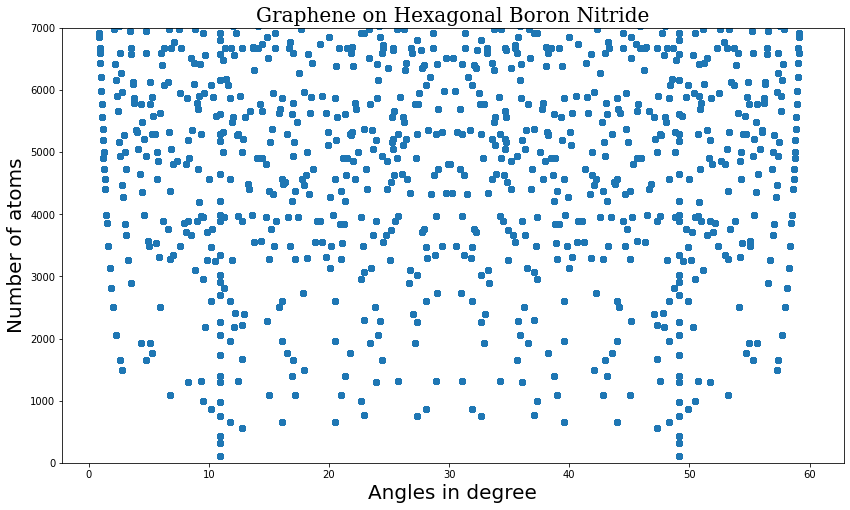

In [34]:
plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

plt.savefig("2.46_2.505.jpg",dpi=400,bbox_inches="tight")

Text(0, 0.5, 'Number of atoms')

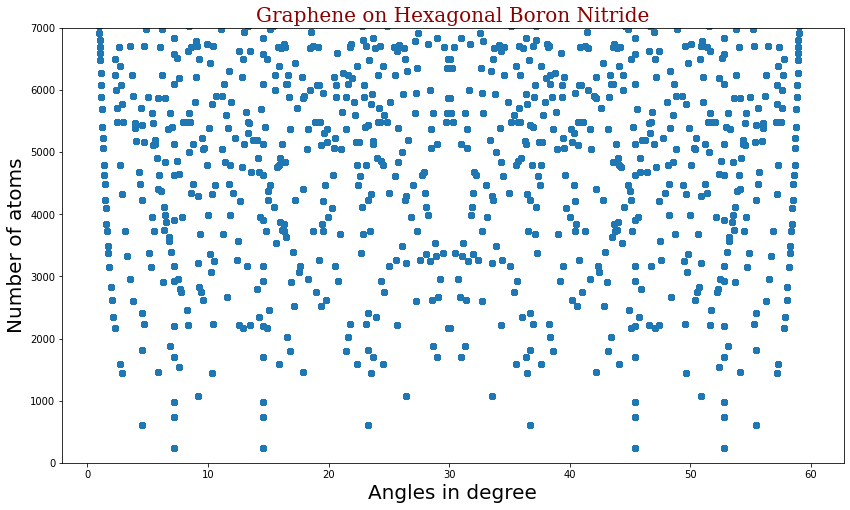

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def supercell_trans_matrices_m(a,b):#Herman equation 25
    m = np.array([[a,b], [-b, a+b]]) # Matrix m
    return m
def supercell_trans_matrices_mp(ap,bp):
    mp = np.array([[ap,bp], [-bp, ap+bp]]) # Matrix m_prime
    return mp

def number_of_moiron(a,b,ap,bp):#Hermann equation 24
    m = supercell_trans_matrices_m(a,b)
    mp = supercell_trans_matrices_mp(ap,bp)
    N = np.linalg.det(m-mp)
    return N

def number_of_atoms_in_1Moiron(a,b,ap,bp): #Hermann equation 30
    A = (ap - a)**2 + (bp - b)**2 + (ap - a)*(bp - b)  #Herman, Equation 31
    x = np.array([[(ap+bp)*(b-bp)+ap*(a-ap), (a*bp - b*ap)], [(b*ap - a*bp), (ap+bp)*(a-ap)+bp*(b-bp)]])
    final_matrix= x/A
    n = np.linalg.det(final_matrix)
    return n * 4 #2 atoms per unit cell in graphene

def total_atoms_per_Supercell(a,b,ap,bp):
    n = number_of_atoms_in_1Moiron(a,b,ap,bp)
    N = number_of_moiron(a,b,ap,bp)
    return round(N*n)

def alpha(a,b,ap,bp,p):#Herman equation 29
#     p = 0.98
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = alpha_rad*180/np.pi
    return alpha_deg

def p_param(a,b,ap,bp):
    return np.sqrt((ap**2+bp**2+ap*bp)/(a**2+b**2+a*b))

def P_range(): # Considering the tolerance of substrate lattice parameters, we will now have a range of 'P' values.
    R0p = 2.50  # Lattice constant of BN
    R0 = 2.46   # Lattice constant of graphene
    tol = 0.001
    return R0/(R0p+tol), R0/(R0p - tol)

plw,phi = P_range()

angles = []
num_atom = []

for a in range(-50,50):
        for b in range(-50,50):
            for ap in range(-50, 50):
                for bp in range(-50,50):
                    if (a != ap and b != bp and a != 0 and b != 0):
                        p = p_param(a,b,ap,bp)
                        if plw <= p <= phi:
                            num_atom.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles.append(angle)

angles2 = [x - 120 if x > 120 else x for x in angles]

angles3 = [x - 60 if x > 60 else x for x in angles2]

plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
        'color':  'darkred','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

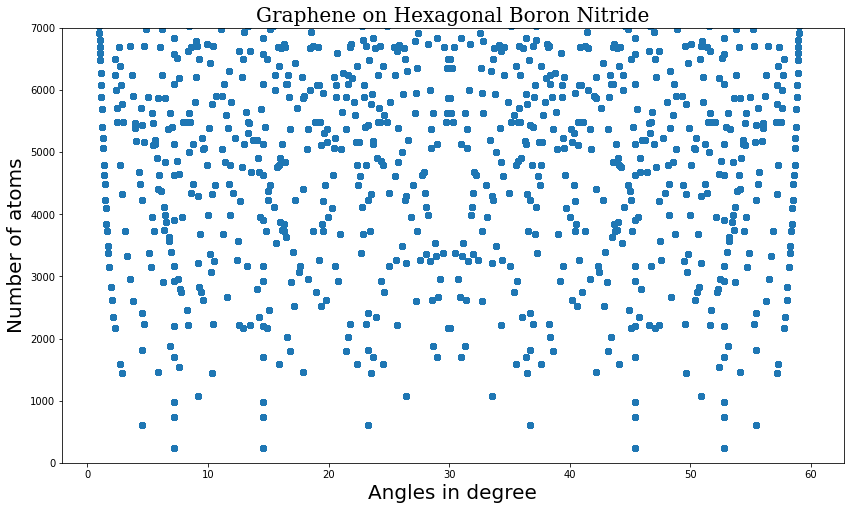

In [32]:
plt.figure(figsize=(14,8))
plt.scatter(angles3,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

plt.savefig("2.46_2.5.jpg",dpi=400,bbox_inches="tight")

Text(0, 0.5, 'Number of atoms')

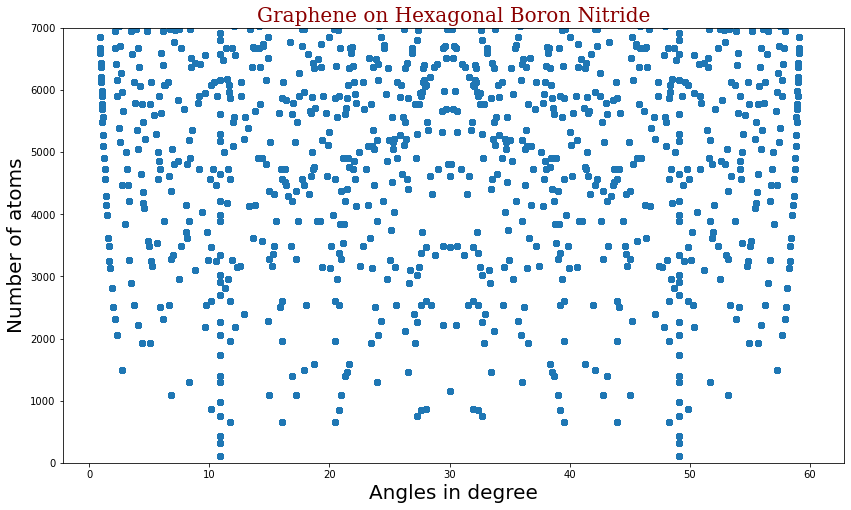

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def supercell_trans_matrices_m(a,b):#Herman equation 25
    m = np.array([[a,b], [-b, a+b]]) # Matrix m
    return m
def supercell_trans_matrices_mp(ap,bp):
    mp = np.array([[ap,bp], [-bp, ap+bp]]) # Matrix m_prime
    return mp

def number_of_moiron(a,b,ap,bp):#Hermann equation 24
    m = supercell_trans_matrices_m(a,b)
    mp = supercell_trans_matrices_mp(ap,bp)
    N = np.linalg.det(m-mp)
    return N

def number_of_atoms_in_1Moiron(a,b,ap,bp): #Hermann equation 30
    A = (ap - a)**2 + (bp - b)**2 + (ap - a)*(bp - b)  #Herman, Equation 31
    x = np.array([[(ap+bp)*(b-bp)+ap*(a-ap), (a*bp - b*ap)], [(b*ap - a*bp), (ap+bp)*(a-ap)+bp*(b-bp)]])
    final_matrix= x/A
    n = np.linalg.det(final_matrix)
    return n * 4 #2 atoms per unit cell in graphene

def total_atoms_per_Supercell(a,b,ap,bp):
    n = number_of_atoms_in_1Moiron(a,b,ap,bp)
    N = number_of_moiron(a,b,ap,bp)
    return round(N*n)

def alpha(a,b,ap,bp,p):#Herman equation 29
#     p = 0.98
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = alpha_rad*180/np.pi
    return alpha_deg

def p_param(a,b,ap,bp):
    return np.sqrt((ap**2+bp**2+ap*bp)/(a**2+b**2+a*b))

def P_range(): # Considering the tolerance of substrate lattice parameters, we will now have a range of 'P' values.
    R0p = 2.505759  # Lattice constant of BN
    R0 = 2.4602   # Lattice constant of graphene
    tol = 0.001
    return R0/(R0p+tol), R0/(R0p - tol)

plw,phi = P_range()

angles = []
num_atom = []
p_change = []

angles1 = []
num_atom1 = []

angles2 = []
num_atom2 = []

angles3 = []
num_atom3 = []

angles4 = []
num_atom4 = []

angles5 = []
num_atom5 = []

for a in range(-50,50):
        for b in range(-50,50):
            for ap in range(-50, 50):
                for bp in range(-50,50):
                    if (a != ap and b != bp and a != 0 and b != 0):
                        p = p_param(a,b,ap,bp)
                        if plw <= p <= phi:
                            num_atom.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles.append(angle)
                            p_change.append(p-(plw+phi)/2)
                        if plw/5 <= p <= phi/5:
                            num_atom1.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles1.append(angle)
                        elif plw*2/5 <= p <= phi*2/5:
                            num_atom2.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles2.append(angle)
                        elif plw*3/5 <= p <= phi*3/5:
                            num_atom3.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles3.append(angle)
                        elif plw*4/5 <= p <= phi*4/5:
                            num_atom4.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles4.append(angle)
                        elif plw <= p <= phi:
                            num_atom5.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles5.append(angle)

anglesA = [x - 120 if x > 120 else x for x in angles]

anglesB = [x - 60 if x > 60 else x for x in anglesA]

plt.figure(figsize=(14,8))
plt.scatter(anglesB,num_atom)
plt.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
        'color':  'darkred','size': 20})
plt.ylim(0, 7000)
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
plt.xlabel("Angles in degree", fontsize = 20)
plt.ylabel("Number of atoms",  fontsize = 20)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

setLatex = False

import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

#import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
import re

import sys
from IPython.display import Math

#from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
#rc('font',**{'family':'serif','serif':['Palatino']})
#rc('text', usetex=True)



from copy import deepcopy

from scipy.spatial import cKDTree
from math import pi, sqrt
#from pybinding.repository.graphene import a, a_cc, t
import pickle
import scipy.ndimage.filters

import matplotlib

from pylab import *

import matplotlib.gridspec as gridspec


def latexify(fig_width=None, fig_height=None, columns=1):
    """Set up matplotlib's RC params for LaTeX plotting.
    Call this before plotting a figure.

    Parameters
    ----------
    fig_width : float, optional, inches
    fig_height : float,  optional, inches
    columns : {1, 2}
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    assert(columns in [1,2])

    if fig_width is None:
        fig_width = 3.39 if columns==1 else 6.9 # width in inches

    if fig_height is None:
        golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
        fig_height = fig_width*golden_mean # height in inches

    #MAX_HEIGHT_INCHES = 7.0
    #if fig_height > MAX_HEIGHT_INCHES:
    #    print("WARNING: fig_height too large:" + fig_height + 
    #          "so will reduce to" + MAX_HEIGHT_INCHES + "inches.")
    #    fig_height = MAX_HEIGHT_INCHES

    params = {'backend': 'ps',
              'text.latex.preamble': [r'\usepackage{gensymb}'],
              'axes.labelsize': 8, # fontsize for x and y labels (was 10)
              'axes.titlesize': 8,
              'font.size': 8, # was 10
              'legend.fontsize': 8, # was 10
              'xtick.labelsize': 8,
              'ytick.labelsize': 8,
              'text.usetex': True,
              'figure.figsize': [fig_width,fig_height],
              #'font.family': 'serif',
              'font.family' : 'Helvetica',
              'figure.autolayout': True,
              'lines.linewidth' : 1.0
    }

    matplotlib.rcParams.update(params)


def format_axes(ax):
    
    SPINE_COLOR = 'gray'

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_tick_params(direction='out', color=SPINE_COLOR)

#q_sigma = c0 * 22.2  # [nm] hopping fitting parameter
#q_pi = a_cc * 22.2  # [nm] hopping fitting parameter
#r0 = 0.184 * a  # [nm] hopping fitting parameter




from mpl_toolkits.axes_grid1 import make_axes_locatable


def getBandstructure(dir1, nPlotBands, EShift):

    f = open(dir1+'/generate.bands.dat','r')
    print(f)
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            print(nbands)
            nk = int(a[7])
            print(nbands,nk)
        if i>16:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                if (int(j)==int(nbands/2-nPlotBands/2 + counterPlotBands) and int(j) < int(nbands/2+nPlotBands/2)):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append(float(a[1])-EShift)
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec

def getSingleBand3(dir1, EShift, bandIndex):

    f = open(dir1+'/generate.bands.dat','r')
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            nk = int(a[7])
            #print(nbands,nk)
        if i>14:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                #print(nbands)
                if (int(j)==int(nbands/2) + bandIndex):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append(float(a[1])-EShift)
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec
                
def getGap(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-1]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [0]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def getGap2(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-3]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [-2]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

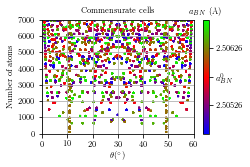

In [42]:
latexify(columns=1)#, fig_height=3.5)  

g1 = gridspec.GridSpec(1, 1)#, height_ratios=[6,1])
g1.update(wspace=0.2, hspace=0.25) # set the spacing between axes.

fig, axes = plt.subplots(1, 1,sharey = "row")

ax0 = subplot(g1[0])


delta = []
for v in p_change:
    d = v*2.505759**2/(2.4602-v*2.505759)
    delta.append(d+2.505759)

im = ax0.scatter(anglesB,num_atom, c=delta, s=1,cmap="brg")
#ax0.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
#        'color':  'darkred','size': 20})
ax0.set_ylim(0, 7000)
ax0.set_xlim(0, 60)
cbar = fig.colorbar(im, ticks=[2.50576-0.0005, 2.50576, 2.50576+0.0005])
cbar.ax.set_yticklabels([2.50526, r'$a_{BN}^0$', 2.50576+0.0005 ])
cbar.ax.set_title(r'$a_{BN}$ (\AA)')
ax0.set_title("Commensurate cells")
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
ax0.set_xlabel(r"$\theta (^\circ)$")#, fontsize = 20)
ax0.set_ylabel("Number of atoms")#,  fontsize = 20)
ax0.grid()

os.chdir("/Users/nihao/Desktop/")
fig.savefig("HermannGBN.png",dpi=1200,bbox_inches='tight')